# Evaluate `gxp_samples.csv`

Input-data explanation notebook for the GTEx tensor view. The tensor plot is driven by the high-level helpers in `src.eval_utils.eval_samples`, so the notebook should stay thin and stable.

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.eval_utils.eval_samples import (
    DEFAULT_TENSOR_AXIS_ASSIGNMENT,
    GTEX_TENSOR_REGION_GROUP,
    GTEX_TENSOR_REGION_ORDER,
    plot_gtex_observation_mask,
    plot_sampled_gtex_tensor,
)


In [36]:
import importlib

import src.eval_utils.eval_samples as eval_samples

importlib.reload(eval_samples)

from src.eval_utils.eval_samples import (
    DEFAULT_TENSOR_AXIS_ASSIGNMENT,
    GTEX_TENSOR_REGION_GROUP,
    GTEX_TENSOR_REGION_ORDER,
    plot_gtex_observation_mask,
    plot_sampled_gtex_tensor,
)


## Setup

In [53]:
CSV_PATH = Path('data/raw/gxp_samples.csv')   # combined samples table to visualize
ACTIVE_GENE_LIST = 'richiardi2015'            # gene panel name or path used for gene subsampling

N_SUBJECTS = 5                               # number of GTEx subjects to sample
N_GENES = 15                                  # number of genes to sample from ACTIVE_GENE_LIST
N_REGIONS = None                              # number of canonical GTEx regions to sample; None keeps all

MIN_REGIONS_PER_SUBJECT = 5                   # only sample subjects with at least this many observed GTEx regions
RANDOM_SEED = 42                              # random seed for subject / gene / region subsampling
MISSING_ALPHA = 1.0                           # alpha for missing region vectors; 1.0 = solid gray

FIGSIZE = (13.5, 9.5)                         # matplotlib figure size
AXES_BBOX = (0.03, 0.06, 0.78, 0.88)          # tensor axes footprint inside the figure
COLORBAR_BBOX = (0.86, 0.16, 0.025, 0.68)     # colorbar footprint inside the figure
BOX_ASPECT = 'compressed_data'                # 'data', 'compressed_data', 'equal', or a 3-tuple
AXIS_ASSIGNMENT = ('gene', 'region', 'subject')  # maps tensor semantics onto (x, y, z)
ELEV = 20.0                                   # vertical camera angle
AZIM = 24.0                                   # horizontal camera angle

SUBJECT_TICK_STEP = 'auto'                    # show every nth subject label; 'auto' adapts to count
REGION_TICK_STEP = None                       # show every nth region label; None means every region
GENE_TICK_STEP = 'auto'                       # show every nth gene label; 'auto' adapts to count
#MAX_SUBJECT_TICKLABELS = 20                   # upper target for visible subject labels when using 'auto'
MAX_REGION_TICKLABELS = 12                    # upper target for visible region labels when using 'auto'
#MAX_GENE_TICKLABELS = 10                      # upper target for visible gene labels when using 'auto'
REGION_TICK_PAD = 20.0                        # padding that pushes region labels off the tensor body

SUBJECT_LABEL_MODE = 'full'                   # 'index', 'suffix', or 'full'
GENE_LABEL_MODE = 'full'                      # 'full' or 'index'

SHOW_AXIS_LABELS = False                      # master switch for axis titles when per-axis overrides are None
SHOW_X_AXIS_LABEL = True                      # override x-axis title visibility independently
SHOW_Y_AXIS_LABEL = None                      # override y-axis title visibility independently
SHOW_Z_AXIS_LABEL = None                      # override z-axis title visibility independently
SHOW_SUBJECT_TICKLABELS = True                # show subject tick labels on the assigned subject axis
SHOW_REGION_TICKLABELS = True                 # show region tick labels on the assigned region axis
SHOW_GENE_TICKLABELS = False                  # show gene tick labels on the assigned gene axis
SHOW_REGION_LABEL_COLORS = False              # color region labels by group when True
SHOW_AXIS_LINES = True                        # show or hide the 3D axis spines
SHOW_TICK_LINES = True                        # show or hide tick marks while keeping labels
SHOW_LEGEND = False                           # show or hide the parcel-group legend


## Canonical GTEx Region Order

In [54]:
pd.DataFrame({
    'order': range(1, len(GTEX_TENSOR_REGION_ORDER) + 1),
    'region': GTEX_TENSOR_REGION_ORDER,
    'group': [GTEX_TENSOR_REGION_GROUP[r] for r in GTEX_TENSOR_REGION_ORDER],
})


,order,region,group
0,1,brain - frontal cortex (ba9),cortical
1,2,brain - anterior cingulate cortex (ba24),cortical
2,3,brain - cortex,cortical
3,4,brain - nucleus accumbens (basal ganglia),basal_ganglia
4,5,brain - caudate (basal ganglia),basal_ganglia
5,6,brain - putamen (basal ganglia),basal_ganglia
6,7,brain - amygdala,limbic_midbrain
7,8,brain - hippocampus,limbic_midbrain
8,9,brain - hypothalamus,limbic_midbrain
9,10,brain - substantia nigra,limbic_midbrain


## Tensor Rendering

/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:68: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


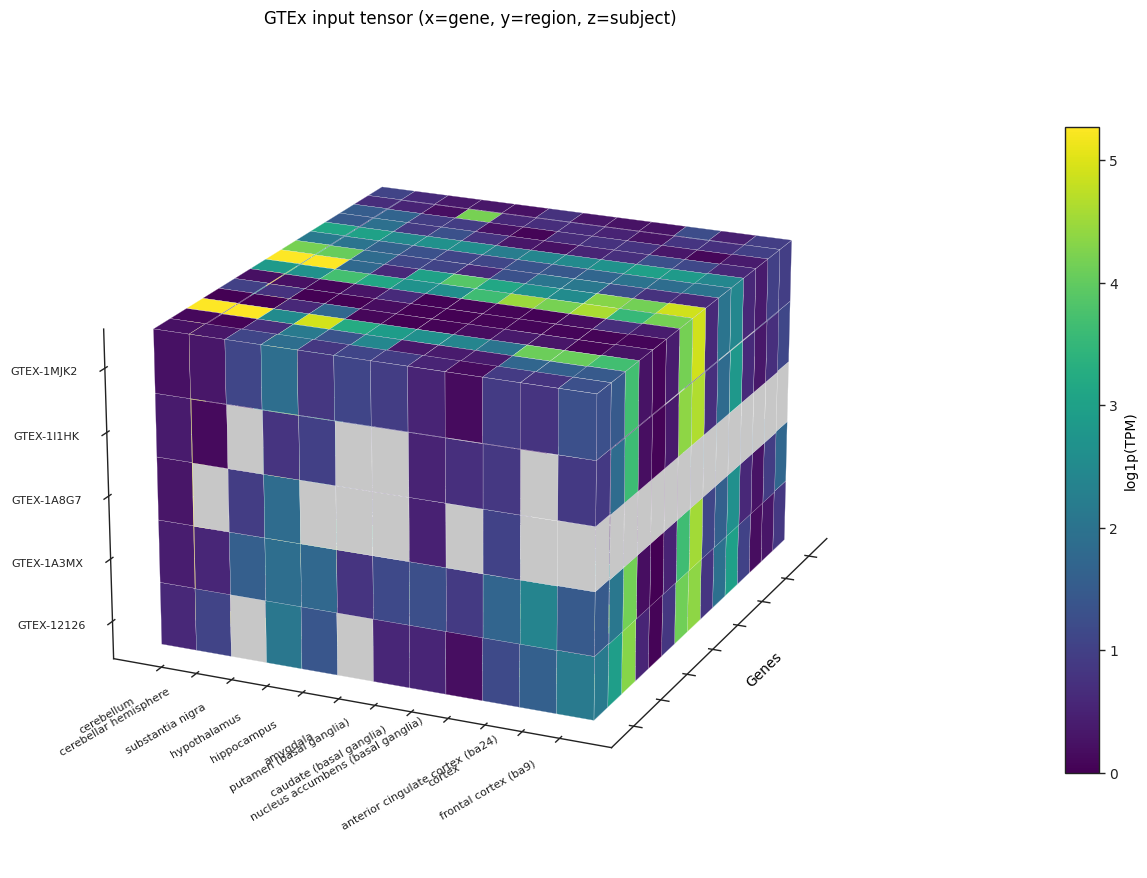

In [55]:
tensor_fig, tensor_ax, tensor_view, selection_summary = plot_sampled_gtex_tensor(
    CSV_PATH,
    gene_panel=ACTIVE_GENE_LIST,
    n_subjects=N_SUBJECTS,
    n_regions=N_REGIONS,
    n_genes=N_GENES,
    min_regions_per_subject=MIN_REGIONS_PER_SUBJECT,
    random_seed=RANDOM_SEED,
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    figsize=FIGSIZE,
    axes_bbox=AXES_BBOX,
    colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT,
    axis_assignment=AXIS_ASSIGNMENT,
    elev=ELEV,
    azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP,
    region_tick_step=REGION_TICK_STEP,
    gene_tick_step=GENE_TICK_STEP,
    max_subject_ticklabels=MAX_SUBJECT_TICKLABELS,
    max_region_ticklabels=MAX_REGION_TICKLABELS,
    max_gene_ticklabels=MAX_GENE_TICKLABELS,
    region_tick_pad=REGION_TICK_PAD,
    show_axis_labels=SHOW_AXIS_LABELS,
    show_x_axis_label=SHOW_X_AXIS_LABEL,
    show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS,
    show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    subject_label_mode=SUBJECT_LABEL_MODE,
    gene_label_mode=GENE_LABEL_MODE,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS,
    show_axis_lines=SHOW_AXIS_LINES,
    show_tick_lines=SHOW_TICK_LINES,
    show_legend=SHOW_LEGEND,
)
plt.show()


## Selection Summary

In [40]:
selection_summary


,selected_subject,selected_region,selected_gene
0,GTEX-11ZUS,brain - frontal cortex (ba9),CALB1
1,GTEX-12WSA,brain - anterior cingulate cortex (ba24),PNMT
2,GTEX-13112,brain - cortex,ONECUT2
3,GTEX-13N2G,brain - nucleus accumbens (basal ganglia),CNTN6
4,GTEX-17HII,brain - caudate (basal ganglia),WNT4
5,GTEX-17JCI,brain - putamen (basal ganglia),RTP1
6,GTEX-1B8SG,brain - amygdala,TSPAN8
7,GTEX-1F48J,brain - hippocampus,PYDC1
8,GTEX-1F52S,brain - hypothalamus,IQCJ
9,GTEX-1HSMO,brain - substantia nigra,SLC20A2


## Observation Mask

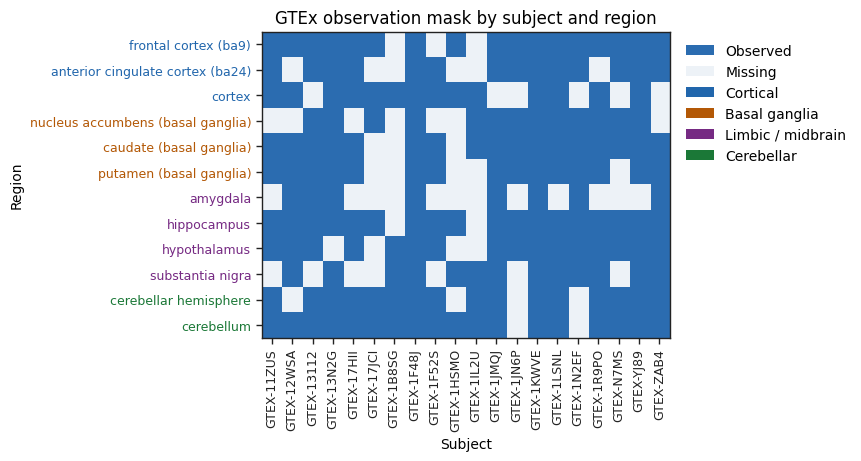

In [41]:
mask_fig, mask_ax = plot_gtex_observation_mask(tensor_view)
plt.show()
